In [86]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score, adjusted_rand_score, normalized_mutual_info_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import VarianceThreshold
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA

| Feature | Description |
|---------|-------------|
| **Gender** | Male / Female |
| **Ever_Married** | Marital status (Yes/No) |
| **Age** | Age of the customer |
| **Graduated** | Whether the customer is a graduate (Yes/No) |
| **Profession** | Profession category (9 types: Artist, Doctor, Engineer, etc.) |
| **Work_Experience** | Years of work experience |
| **Spending_Score** | Spending behavior (Low / Average / High) |
| **Family_Size** | Number of family members |
| **Var_1** | Anonymized customer category |
| **Segmentation** | Pre-labeled customer segment (A/B/C/D) |

In [80]:
data = pd.read_csv('../datasets/customer_segmentation.csv')
data

,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,462809,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4,D
1,462643,Female,Yes,38,Yes,Engineer,NaN,Average,3.0,Cat_4,A
2,466315,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6,B
3,461735,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6,B
4,462669,Female,Yes,40,Yes,Entertainment,NaN,High,6.0,Cat_6,A
...,...,...,...,...,...,...,...,...,...,...,...
8063,464018,Male,No,22,No,NaN,0.0,Low,7.0,Cat_1,D
8064,464685,Male,No,35,No,Executive,3.0,Low,4.0,Cat_4,D
8065,465406,Female,No,33,Yes,Healthcare,1.0,Low,1.0,Cat_6,D
8066,467299,Female,No,27,Yes,Healthcare,1.0,Low,4.0,Cat_6,B


In [82]:
# feature selection
categorical_features = data.drop(['Segmentation'], axis=1).select_dtypes(include=['category', 'object']).columns
numerical_features = data.drop(['ID'], axis=1).select_dtypes(include=['number']).columns

# handle missing data
data = data.dropna(subset=categorical_features)
data = data.fillna(value=data[numerical_features].mean())

# data
X = pd.concat([data[categorical_features], data[numerical_features]], axis=1)

# true labels
true_label = data['Segmentation']

# pipeline
categorical_transformer = Pipeline([
    ('one_hot', OneHotEncoder(drop='first', sparse_output=False))
])

numerical_transformer = Pipeline([
    ('scalar', StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

# optimal k 
best_k, best_score = 1, 0
X_transformed = preprocessor.fit_transform(X)

for k in range(2, 12):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_transformed)
    silhouette_scores = silhouette_score(X_transformed, cluster_labels)

    best_k, best_score = (k, silhouette_scores) if silhouette_scores > best_score else (best_k, best_score)


kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_transformed)
silhouette_scores = silhouette_score(X_transformed, cluster_labels)

data['cluster_labels'] = cluster_labels
print(f'score = {silhouette_scores:.3f}')

score = 0.205


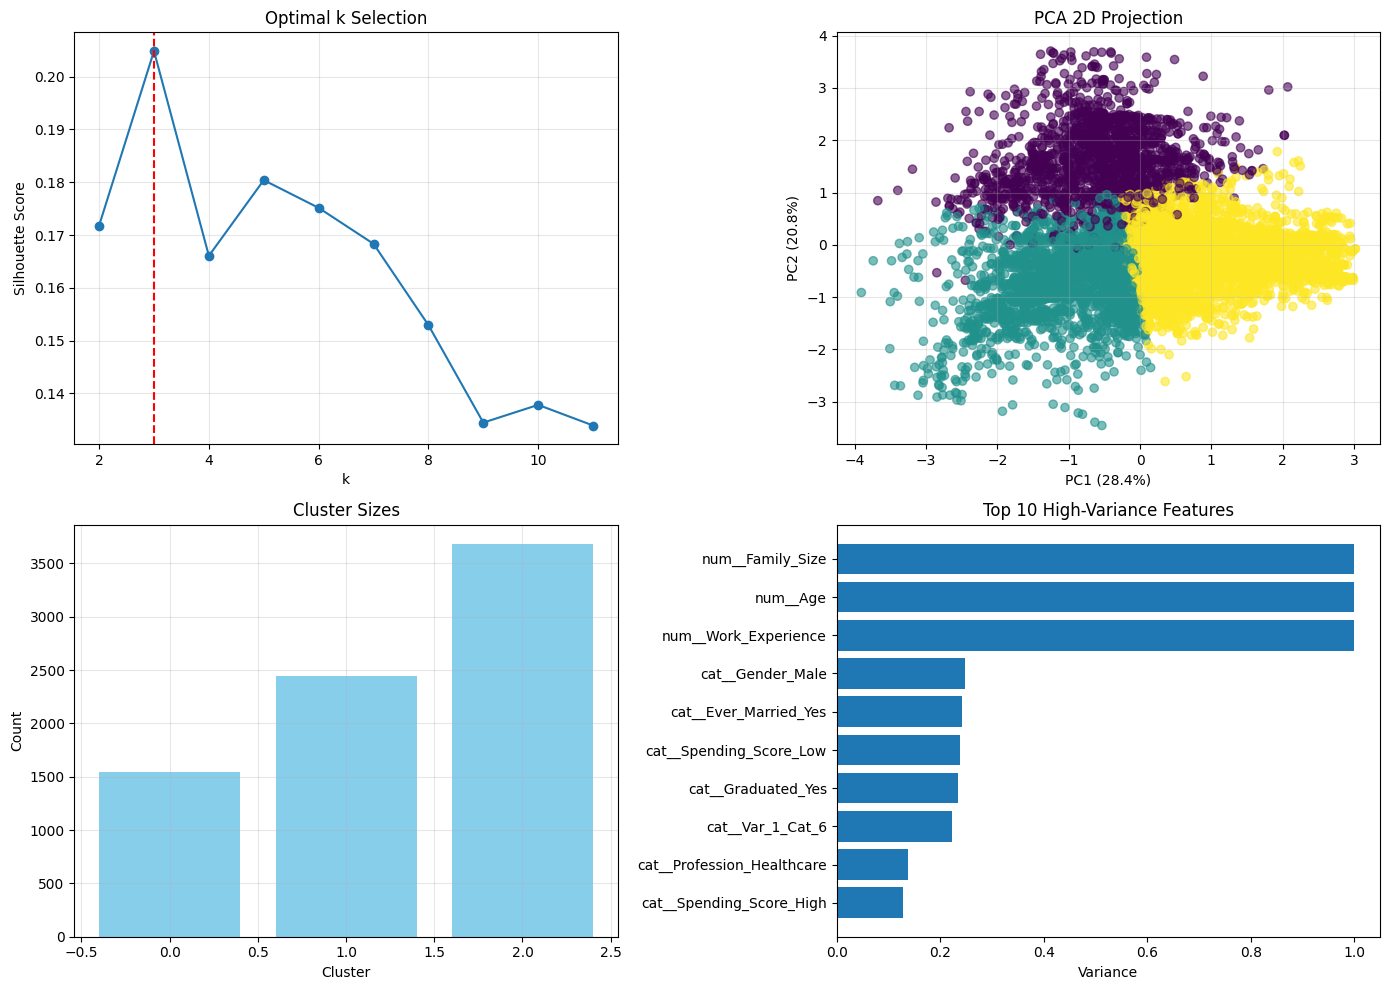

In [87]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Silhouette Score per k
scores = []
for k in range(2, 12):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_transformed)
    scores.append(silhouette_score(X_transformed, labels))

axes[0, 0].plot(range(2, 12), scores, marker='o')
axes[0, 0].axvline(x=best_k, color='red', linestyle='--')
axes[0, 0].set_xlabel('k')
axes[0, 0].set_ylabel('Silhouette Score')
axes[0, 0].set_title('Optimal k Selection')
axes[0, 0].grid(True, alpha=0.3)

# 2. PCA 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_transformed)
axes[0, 1].scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='viridis', alpha=0.6)
axes[0, 1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[0, 1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
axes[0, 1].set_title('PCA 2D Projection')
axes[0, 1].grid(True, alpha=0.3)

# 3. Cluster sizes
cluster_sizes = pd.Series(cluster_labels).value_counts().sort_index()
axes[1, 0].bar(cluster_sizes.index, cluster_sizes.values, color='skyblue')
axes[1, 0].set_xlabel('Cluster')
axes[1, 0].set_ylabel('Count')
axes[1, 0].set_title('Cluster Sizes')
axes[1, 0].grid(True, alpha=0.3)

# 4. Feature variance
feature_var = np.var(X_transformed, axis=0)
feature_names = preprocessor.get_feature_names_out()
top_indices = np.argsort(feature_var)[-10:]
axes[1, 1].barh(feature_names[top_indices], feature_var[top_indices])
axes[1, 1].set_xlabel('Variance')
axes[1, 1].set_title('Top 10 High-Variance Features')

plt.tight_layout()
plt.show()

In [76]:
X_processed = pd.DataFrame(X_transformed, columns = preprocessor.get_feature_names_out())

# feature selection using varicnce
for threshold in [0.05, 0.1, 0.2, 0.5]:
    selector = VarianceThreshold(threshold=threshold)
    X_selected = selector.fit_transform(X_processed)
    n_selected = X_selected.shape[1]
    print(f"Threshold {threshold}: {n_selected} features selected")

# Use a threshold that removes some features
selector = VarianceThreshold(threshold=0.1)  # based on above
X_selected = selector.fit_transform(X_processed)
selected_features = X_processed.columns[selector.get_support()].tolist()
print("="*50)
print("Feature Selection Using variance")
print("="*50)
print(f"Selected: {selected_features}")


# feature selection using random forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_processed, data['Segmentation'])

importance_df = pd.DataFrame({
    'feature': X_processed.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print()
print("="*50)
print("Feature Selection Using Random Forest")
print("="*50)
print(importance_df)

# Select top features (e.g., top 5, or those above 0.05)
threshold = 0.05
selected_features = importance_df[importance_df['importance'] > threshold]['feature'].tolist()
print(f"\nSelected features (importance > {threshold}): {selected_features}")

Threshold 0.05: 18 features selected
Threshold 0.1: 12 features selected
Threshold 0.2: 8 features selected
Threshold 0.5: 3 features selected
Feature Selection Using variance
Selected: ['num__Age', 'num__Work_Experience', 'num__Family_Size', 'cat__Gender_Male', 'cat__Ever_Married_Yes', 'cat__Graduated_Yes', 'cat__Profession_Entertainment', 'cat__Profession_Healthcare', 'cat__Spending_Score_High', 'cat__Spending_Score_Low', 'cat__Var_1_Cat_4', 'cat__Var_1_Cat_6']

Feature Selection Using Random Forest
                          feature  importance
0                        num__Age    0.354456
1            num__Work_Experience    0.161365
2                num__Family_Size    0.117982
5              cat__Graduated_Yes    0.039761
15        cat__Spending_Score_Low    0.039627
10     cat__Profession_Healthcare    0.038408
3                cat__Gender_Male    0.036759
4           cat__Ever_Married_Yes    0.034915
8   cat__Profession_Entertainment    0.019647
20               cat__Var_1_Cat_6